In [40]:
import sys
sys.path.append("..")
%run "../moduli.py"

In [41]:
pesata = False

# Lettura

In [42]:
par_labels = [
    r"$\Delta f_{A_{\mathrm{fit}}}$",
    r"$\Delta f_{\Delta \Phi_{\mathrm{fit}}}$",  # da regressione

    r"$\Delta f_{A}$",
    r"$\Delta f_{\Delta \Phi}$",  # fatti da Zoya
]

par = [Misura(None, None) for _ in range(len(par_labels))]

Lettura Pickle ampiezza

In [43]:
a = Misura(None, None)
b = Misura(None, None)
c = Misura(None, None)
anal,offset = let.importa_pickle("ampiezza.pkl")
[[a.val, b.val, c.val], [a.s, b.s, c.s]] = anal
[x_off, y_off] = offset
del anal,offset

df = (2 * c.val) / (2 * np.pi)
sdf = (2 * c.s) / (2 * np.pi)
par[0] = Misura(df, sdf)
print(par[0])

7307.486707101424 ± 47.03835134759923


Lettura Pickle sfasamento

In [44]:
a = Misura(None, None)
b = Misura(None, None)
anal,offset = let.importa_pickle("sfasamento.pkl")
[[a.val, b.val], [a.s, b.s]] = anal
[x_off, y_off] = offset
del anal,offset

delta = a.val / (2*b.val)
sdelta = delta * np.sqrt( (a.s/a.val)**2 + (b.s/b.val)**2)

df = abs(( 2 * delta ) / (2 * np.pi))
sdf = (2 * sdelta) / (2 * np.pi)

par[1] = Misura(df, sdf)
print(par[1])

10839.785803133116 ± 138.41814403299747


Misure di f0 nel Latex

In [45]:
par[2] = Misura(10.7e3,0.3e3)
par[3] = Misura(10.9e3,0.1e3)

Conversione

In [46]:
valori = np.array([m.val for m in par])
errori = np.array([m.s for m in par])

par = Misura(valori, errori)
par_star = Misura(valori[1:],errori[1:])
del valori,errori

# Analisi

In [47]:
if pesata:
    media = an.media_p(par)
    media_star = an.media_p(par_star)
elif not pesata:
    media = an.media(par)
    media_star = an.media(par_star)

In [48]:
x = list(range(len(par_labels)))

In [53]:
residui = []
residui_star = []

for i in range(len(par_labels)):
    res = (media.val - par.val[i])
    residui.append([x[i], res, par.s[i]])
    res = (media_star.val - par.val[i])
    residui_star.append([x[i], res, par.s[i]])

residui = np.array(residui)
res = np.array([residui[:, 0], residui[:, 1], residui[:, 2]])
residui_star = np.array(residui_star)
res_star = np.array([residui_star[:, 0], residui_star[:, 1], residui_star[:, 2]])

# Grafico

In [50]:
titolo = "Confronto stime larghezza di banda"

ylabel = "\Delta f"
yunit = "Hz"

file_output1 = "confronto_df.pdf"

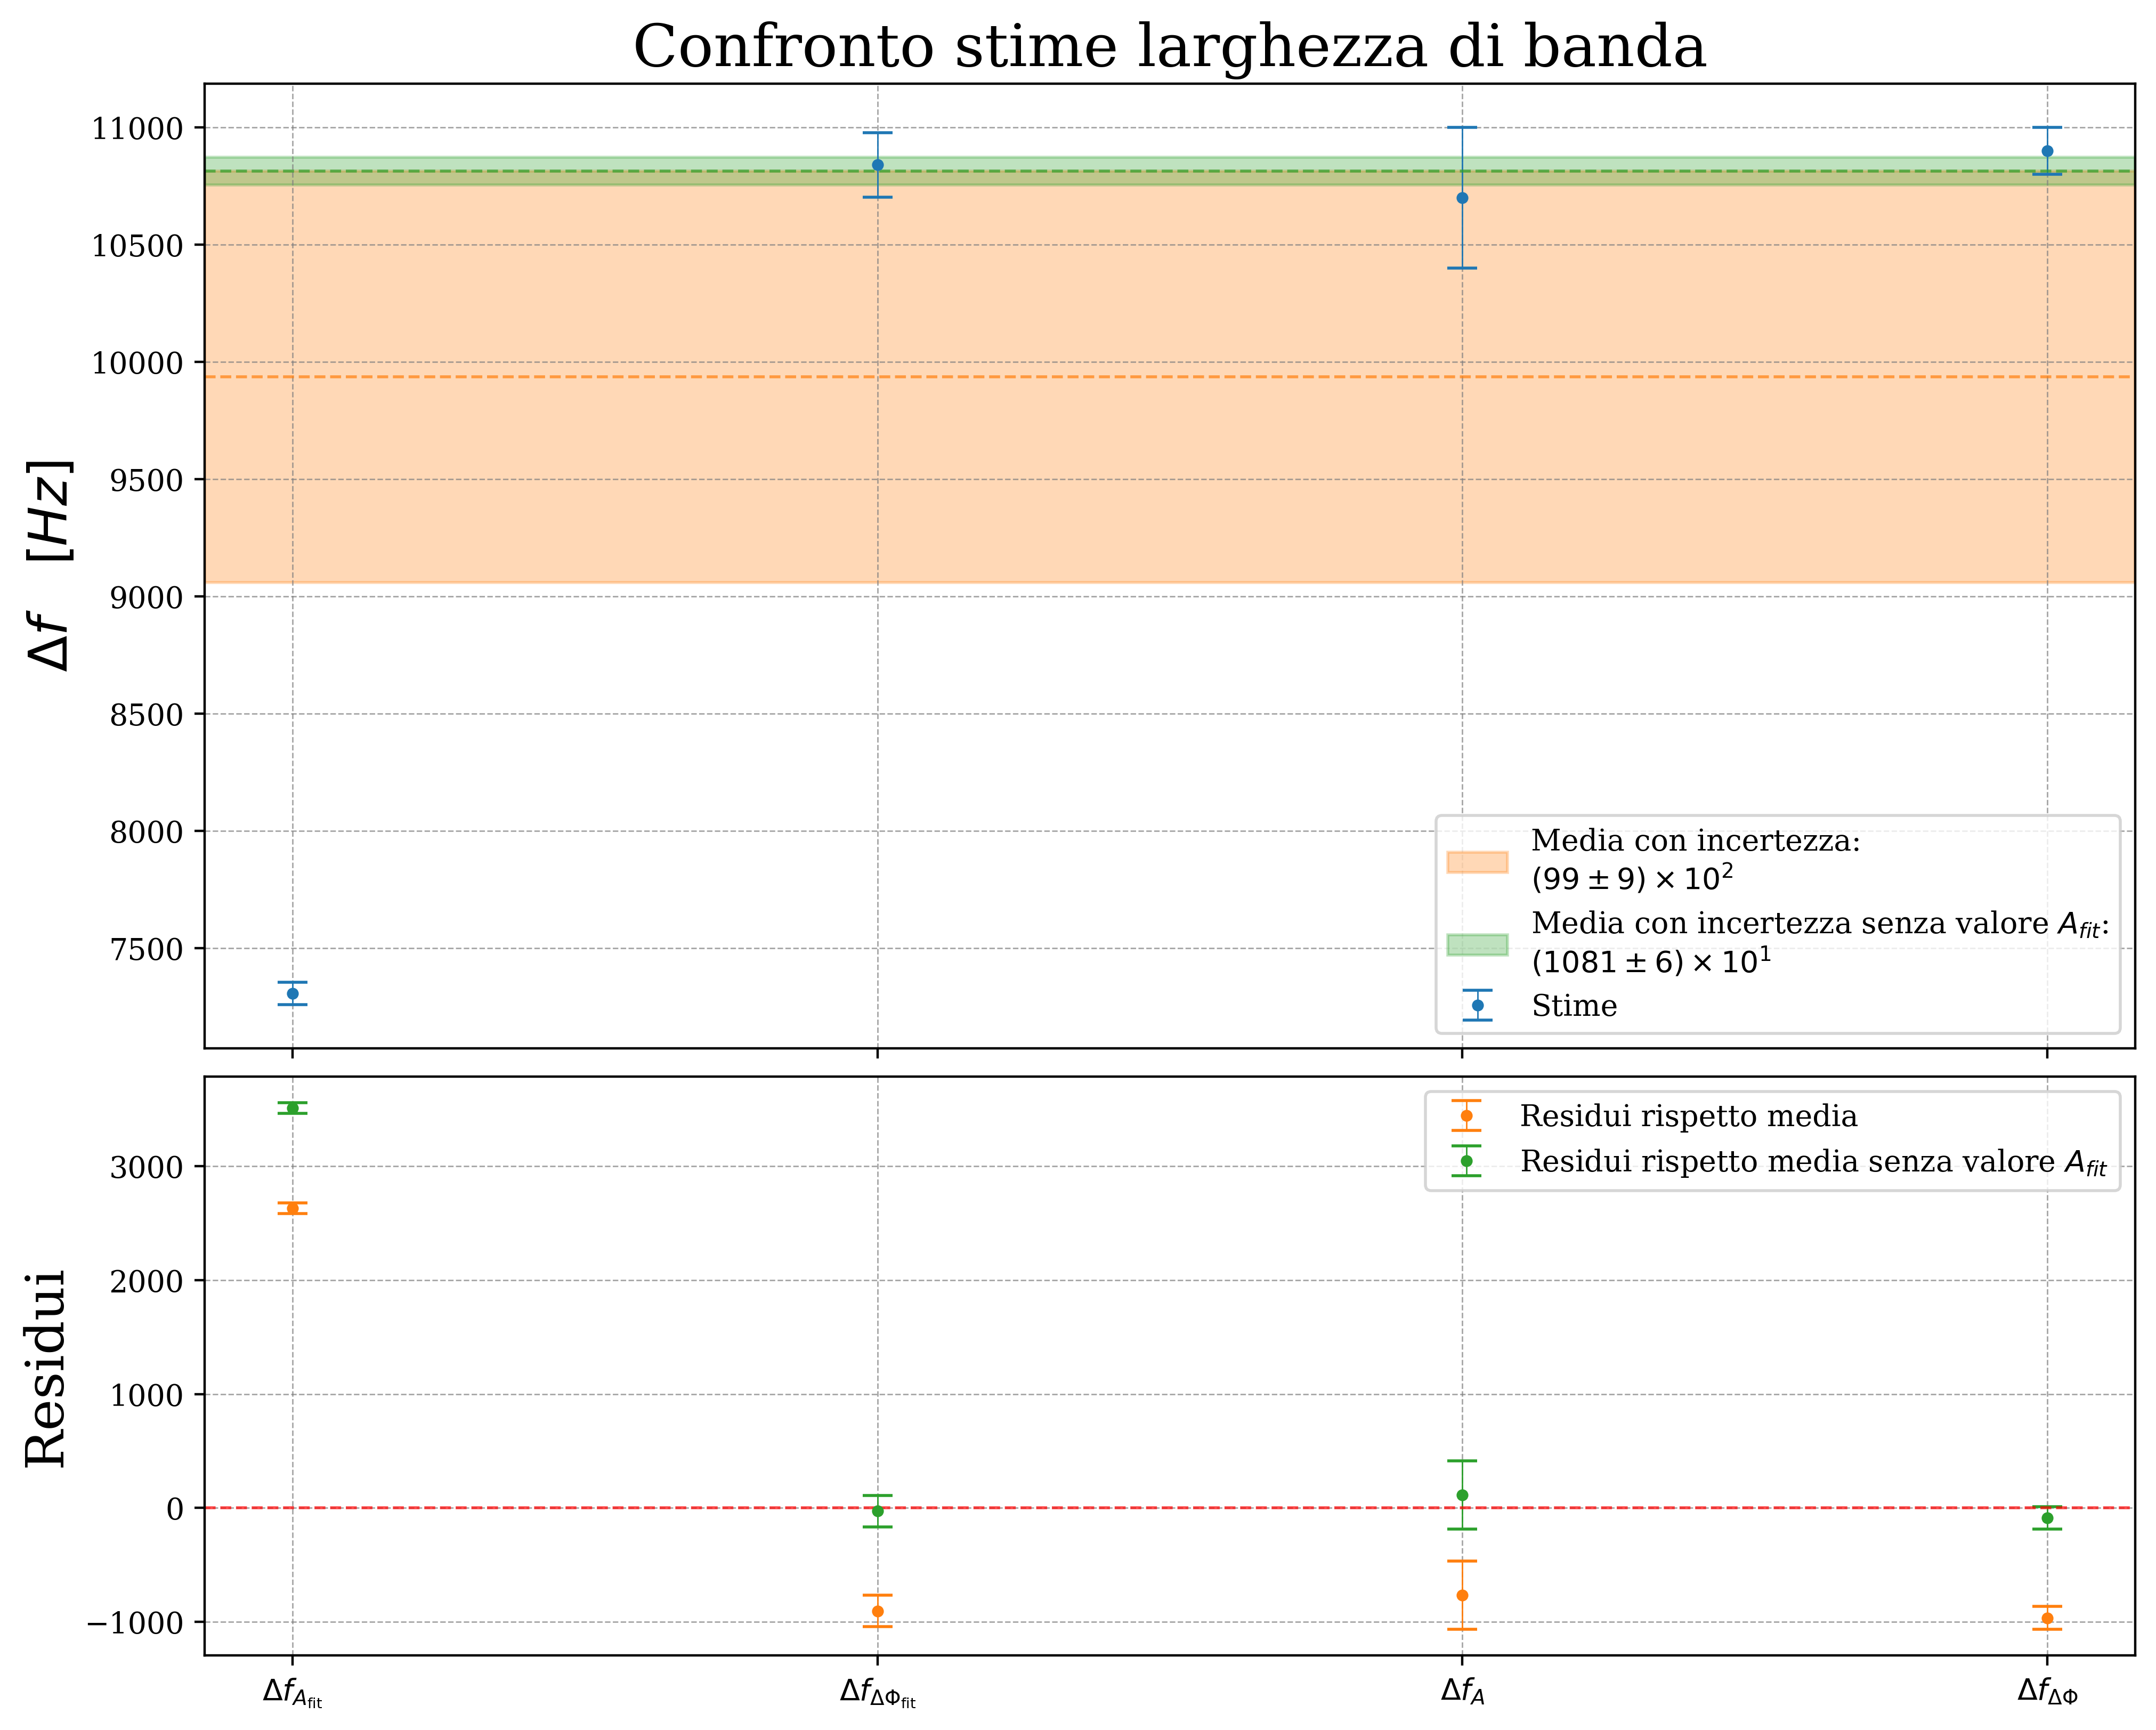

In [56]:
fig1, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(10, 8),
        gridspec_kw={'height_ratios': [5, 3]},
        constrained_layout=True,
        sharex=True
)
ax1.tick_params(axis='x', labelbottom=False)
gf.parametri_grafico(ax1, f"{titolo}", ylabel= rf"${ylabel}\quad [{yunit}]$")
gf.parametri_grafico(ax2, ylabel="Residui")

ax2.set_xticks(range(len(par_labels)))
ax2.set_xticklabels(par_labels)

# Dati
ax1.errorbar(
    x,
    par.val,
    yerr=par.s,
    label="Stime",
    **gf.errorbar_params,
    color = gf.colori[0]
)

# Media
ax1.axhline(
    media.val,
    **gf.line_params,
    color=gf.colori[1]
)
if pesata:
    label = "Media pesata con incertezza:\n"
elif not pesata:
    label = "Media con incertezza:\n"
ax1.axhspan(
    media.val - media.s,
    media.val + media.s,
    alpha=0.3,
    color=gf.colori[1],
    label=label + f"${gf.formatta_errore(media.val,media.s)}$"
)

# Media star
ax1.axhline(
    media_star.val,
    **gf.line_params,
    color=gf.colori[2]
)
if pesata:
    label = "Media pesata con incertezza:\n"
elif not pesata:
    label = "Media con incertezza senza valore $A_{fit}$:\n"
ax1.axhspan(
    media_star.val - media_star.s,
    media_star.val + media_star.s,
    alpha=0.3,
    color=gf.colori[2],
    label=label + f"${gf.formatta_errore(media_star.val,media_star.s)}$"
)

ax1.legend(loc="lower right", bbox_to_anchor=(1,0), fontsize=10)

# Residui
ax2.errorbar(
    res[0],
    res[1],
    yerr=res[2],
    **gf.errorbar_params,
    color=gf.colori[1],
    label="Residui rispetto media"
)

ax2.errorbar(
    res_star[0],
    res_star[1],
    yerr=res_star[2],
    **gf.errorbar_params,
    color=gf.colori[2],
    label="Residui rispetto media senza valore $A_{fit}$"
)

ax2.legend(loc="upper right", bbox_to_anchor=(1,1), fontsize=10)

# Linea orizzontale
ax2.axhline(
    0,
    **gf.line_params,
    color="red"
)

let.salva_grafico(fig1, file_output1)

In [52]:
print(par)

7307.486707101424 ± 47.03835134759923
10839.785803133116 ± 138.41814403299747
10700.0 ± 300.0
10900.0 ± 100.0

